# Compare two-turbine simulation

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import time
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from mpl_toolkits.axes_grid1 import make_axes_locatable

import pickle

In [2]:
import sys, os
curdir = os.getcwd()
extradirs = ['../', '../../',
             '../../SANDwake3D',
             os.path.dirname(curdir),
            ]
for x in extradirs: sys.path.insert(1, x)

In [3]:
def loadpickle(picklefile):
    pfile          = open(picklefile, 'rb')
    ds             = pickle.load(pfile)
    pfile.close()
    return ds

find_nearest = lambda a, a0: np.abs(np.array(a) - a0).argmin()

plotLESTKE = lambda d, ii: 0.5*(d['uu_avg'][ii,:,:]+d['vv_avg'][ii,:,:]+d['ww_avg'][ii,:,:])

In [4]:
# Load RANS solution
loadpklfile = 'Phi_MedWS_LowTI.pkl'
db = loadpickle(loadpklfile)
params = db['params']
xvec   = db['xvec']
phi    = db['phi']

In [5]:
zvec=params['zm'][0,:]
yvec=params['ym'][:,0]
xm, ym = np.meshgrid(xvec, yvec)
izRANS = find_nearest(zvec, 150.0)

In [6]:
turbD  = 240
turbhh = 150
LES_turbx = 1200
LES_turby = 1000
RANS_turbx = 120

maxV=2.5
maxL=0.5
maxP=0.01
maxK=3.0
vlevels={'u':{'levels':np.linspace(0,12,121), 'cbarticks':np.arange(0,12,1)},
         'v':{'levels':np.linspace(-maxV,maxV,41), 'cbarticks':np.arange(-maxV, maxV+1E-5,maxV/5)},
         'w':{'levels':np.linspace(-maxL,maxL,41), 'cbarticks':np.arange(-maxL, maxL+1E-5,maxL/5)}, 
         'k':{'levels':np.linspace(0,maxK,41), 'cbarticks':np.arange(0, maxK,maxK/5)}, 
         'p':{'levels':np.linspace(-maxP,maxP,41), 'cbarticks':np.arange(-maxP, maxP+1E-5,maxP/5)}, 
        }

plotv = 'u'

In [7]:
savefigs = True
figdir   = 'figures/'

## Compare XY TKE planes

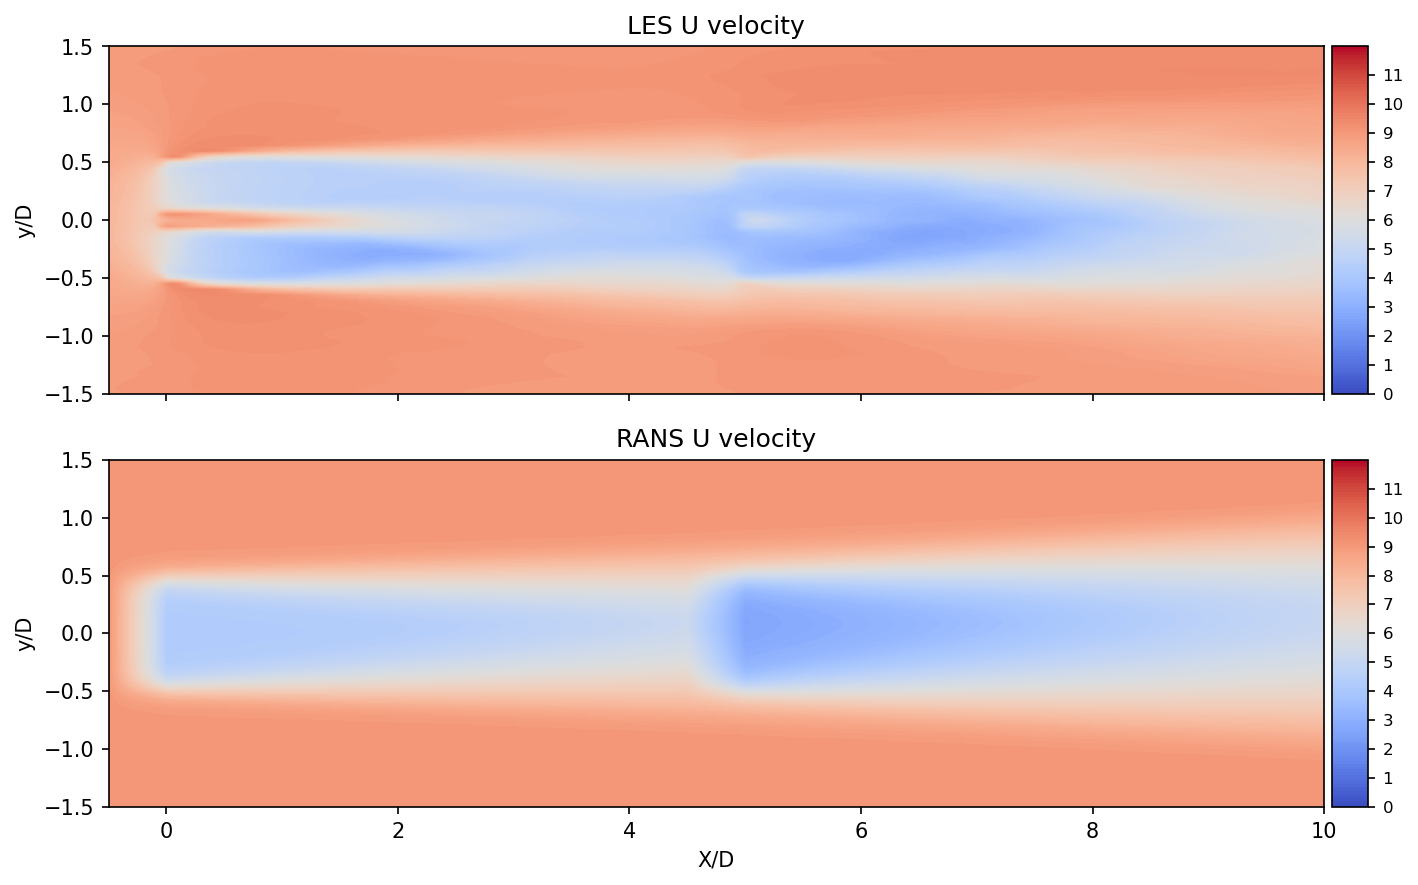

In [8]:
# Load the LES data
XY_wake = loadpickle('XYplanes/XY_wake.pkl')

c={}
fig, axs = plt.subplots(2,1,figsize=(10,6), dpi=150, sharex=True)

# Plot LES
c[0] = axs[0].contourf((XY_wake['x'][1,:,:]-LES_turbx)/turbD, (XY_wake['y'][1,:,:]-LES_turby)/turbD, XY_wake['velocityx_avg'][1,:,:], levels=vlevels[plotv]['levels'], cmap='coolwarm')

# Plot RANS
c[1] = axs[1].contourf((xm-RANS_turbx)/turbD, ym/turbD, phi[plotv][:,:,izRANS].transpose(), levels=vlevels[plotv]['levels'], cmap='coolwarm')

for ix, ax in enumerate(axs[:]):
    ax.set_xlim([-0.5,10])
    ax.set_ylim([-1.5, 1.5])
    ax.set_aspect('equal')
    
    divider = make_axes_locatable(axs[ix])
    cax = divider.append_axes("right", size="3%", pad=0.05)
    cbar=fig.colorbar(c[ix], ax=axs[ix], cax=cax, ticks = matplotlib.ticker.FixedLocator(vlevels[plotv]['cbarticks']))
    cbar.ax.tick_params(labelsize=8)
    
    ax.set_ylabel('y/D')
    
axs[1].set_xlabel('X/D')
axs[0].set_title('LES U velocity')
axs[1].set_title('RANS U velocity')

plt.tight_layout()
    
if savefigs:
    plt.savefig(figdir+'/MedWS_LowTI_2Turb_XY_HH_U.png')

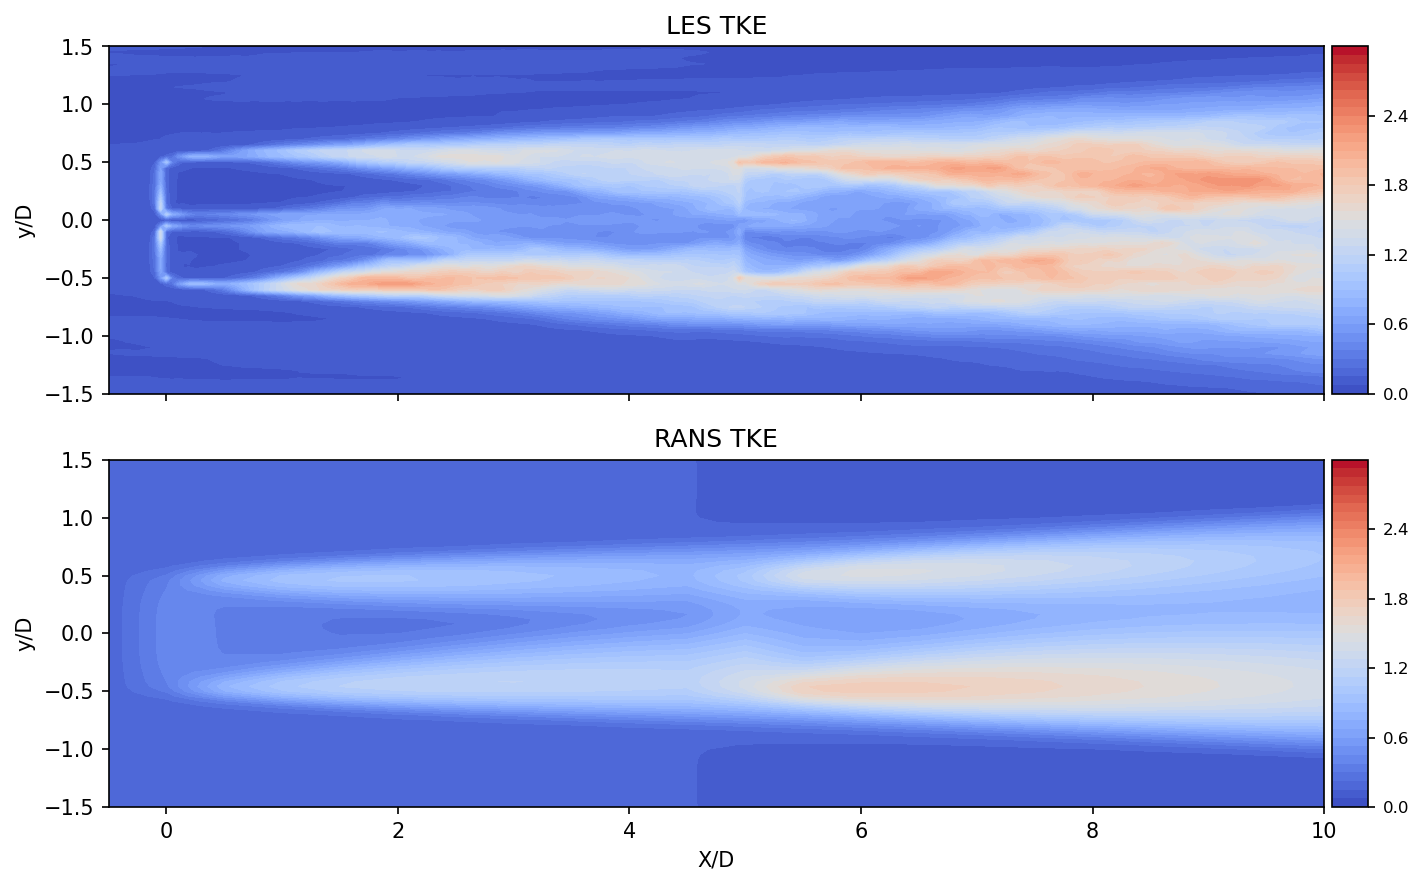

In [9]:
# Load the LES data
XY_wake = loadpickle('XYplanes/XY_wake_TKE.pkl')
LES_TKE = plotLESTKE(XY_wake, 1)

plotv='k'

c={}
fig, axs = plt.subplots(2,1,figsize=(10,6), dpi=150, sharex=True)

# Plot LES
c[0] = axs[0].contourf((XY_wake['x'][1,:,:]-LES_turbx)/turbD, (XY_wake['y'][1,:,:]-LES_turby)/turbD, LES_TKE, levels=vlevels[plotv]['levels'], cmap='coolwarm')

# Plot RANS
c[1] = axs[1].contourf((xm-RANS_turbx)/turbD, ym/turbD, phi[plotv][:,:,izRANS].transpose(), levels=vlevels[plotv]['levels'], cmap='coolwarm')

for ix, ax in enumerate(axs[:]):
    ax.set_xlim([-0.5,10])
    ax.set_ylim([-1.5, 1.5])
    ax.set_aspect('equal')
    
    divider = make_axes_locatable(axs[ix])
    cax = divider.append_axes("right", size="3%", pad=0.05)
    cbar=fig.colorbar(c[ix], ax=axs[ix], cax=cax, ticks = matplotlib.ticker.FixedLocator(vlevels[plotv]['cbarticks']))
    cbar.ax.tick_params(labelsize=8)
    
    ax.set_ylabel('y/D')
    
axs[1].set_xlabel('X/D')
axs[0].set_title('LES TKE')
axs[1].set_title('RANS TKE')
plt.tight_layout()

if savefigs:
    plt.savefig(figdir+'/MedWS_LowTI_2Turb_XY_HH_TKE.png')

## Compare YZ planes

In [10]:
plotdict = [
    # x/D = 2
    {'LES_YZfile':'YZplanes/YZ_wake3.pkl', 
     'LES_turbx':LES_turbx, 
     'LES_turby':LES_turby, 
     'LES_iplane':0,  
     'LES_plotvar':'velocityx_avg',
     'RANS_turbx':RANS_turbx,
     'RANS_plotvar':'u',
     'turbD':turbD,
     'turbhh':turbhh,
     'savefig':figdir+'/MedWS_LowTI_2Turb_LES_RANS_U_YZ_2D.png',
    },
    
    # x/D = 4
    {'LES_YZfile':'YZplanes/YZ_wake3.pkl', 
     'LES_turbx':LES_turbx, 
     'LES_turby':LES_turby, 
     'LES_iplane':4,  
     'LES_plotvar':'velocityx_avg',
     'RANS_turbx':RANS_turbx,
     'RANS_plotvar':'u',
     'turbD':turbD,
     'turbhh':turbhh,
     'savefig':figdir+'/MedWS_LowTI_2Turb_LES_RANS_U_YZ_4D.png',
    },

    # x/D = 5
    {'LES_YZfile':'YZplanes/YZ_wake4.pkl', 
     'LES_turbx':LES_turbx, 
     'LES_turby':LES_turby, 
     'LES_iplane':0,  
     'LES_plotvar':'velocityx_avg',
     'RANS_turbx':RANS_turbx,
     'RANS_plotvar':'u',
     'turbD':turbD,
     'turbhh':turbhh,
     'savefig':figdir+'/MedWS_LowTI_2Turb_LES_RANS_U_YZ_5D.png',
    },
    
    # x/D = 6
    {'LES_YZfile':'YZplanes/YZ_wake4.pkl', 
     'LES_turbx':LES_turbx, 
     'LES_turby':LES_turby, 
     'LES_iplane':1,  
     'LES_plotvar':'velocityx_avg',
     'RANS_turbx':RANS_turbx,
     'RANS_plotvar':'u',
     'turbD':turbD,
     'turbhh':turbhh,
     'savefig':figdir+'/MedWS_LowTI_2Turb_LES_RANSU_YZ_6D.png',
    },

    # x/D = 8
    {'LES_YZfile':'YZplanes/YZ_wake4.pkl', 
     'LES_turbx':LES_turbx, 
     'LES_turby':LES_turby, 
     'LES_iplane':3,  
     'LES_plotvar':'velocityx_avg',
     'RANS_turbx':RANS_turbx,
     'RANS_plotvar':'u',
     'turbD':turbD,
     'turbhh':turbhh,
     'savefig':figdir+'/MedWS_LowTI_2Turb_LES_RANS_U_YZ_8D.png',
    },

    # x/D = 9
    {'LES_YZfile':'YZplanes/YZ_wake4.pkl', 
     'LES_turbx':LES_turbx, 
     'LES_turby':LES_turby, 
     'LES_iplane':4,  
     'LES_plotvar':'velocityx_avg',
     'RANS_turbx':RANS_turbx,
     'RANS_plotvar':'u',
     'turbD':turbD,
     'turbhh':turbhh,
     'savefig':figdir+'/MedWS_LowTI_2Turb_LES_RANS_U_YZ_9D.png',
    },

]

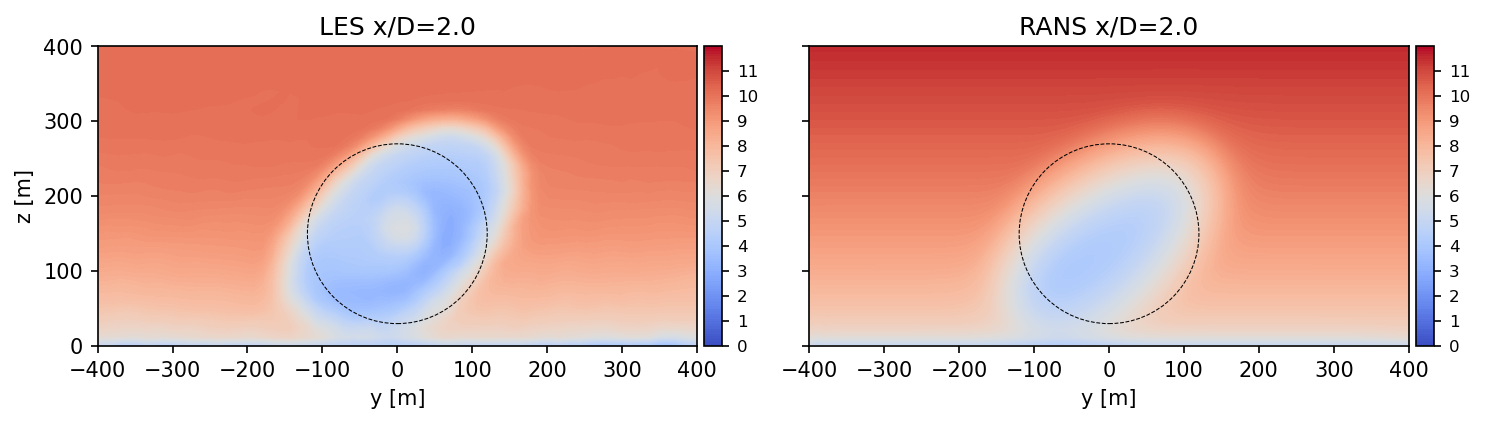

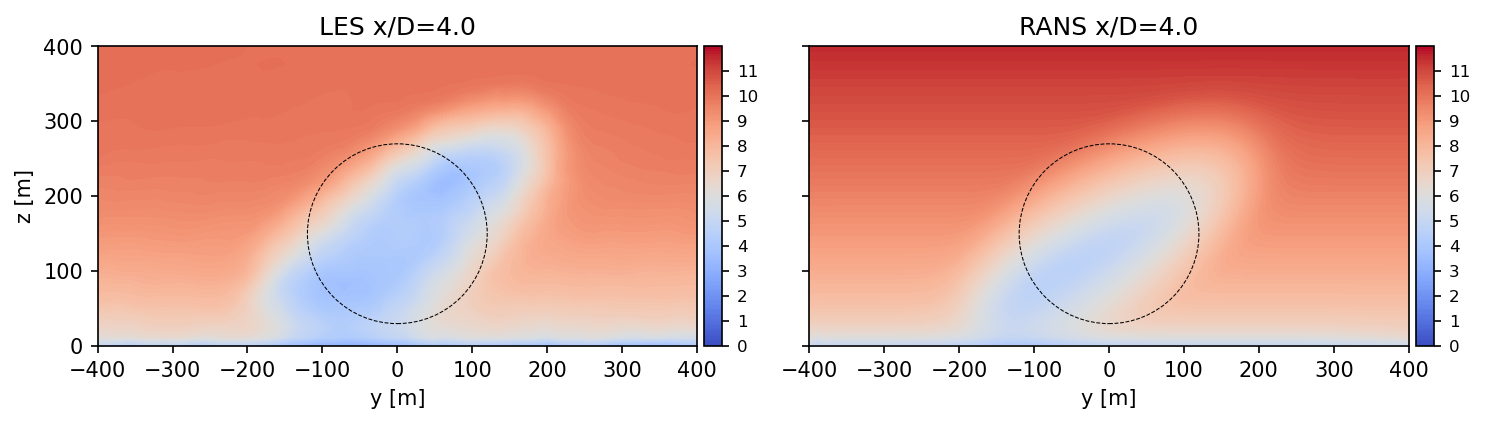

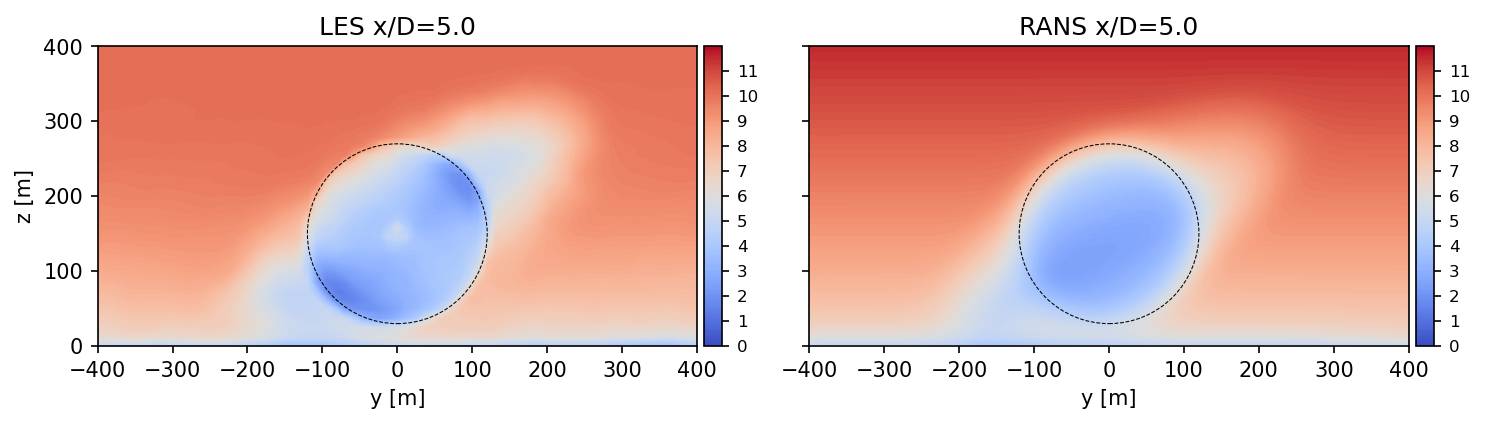

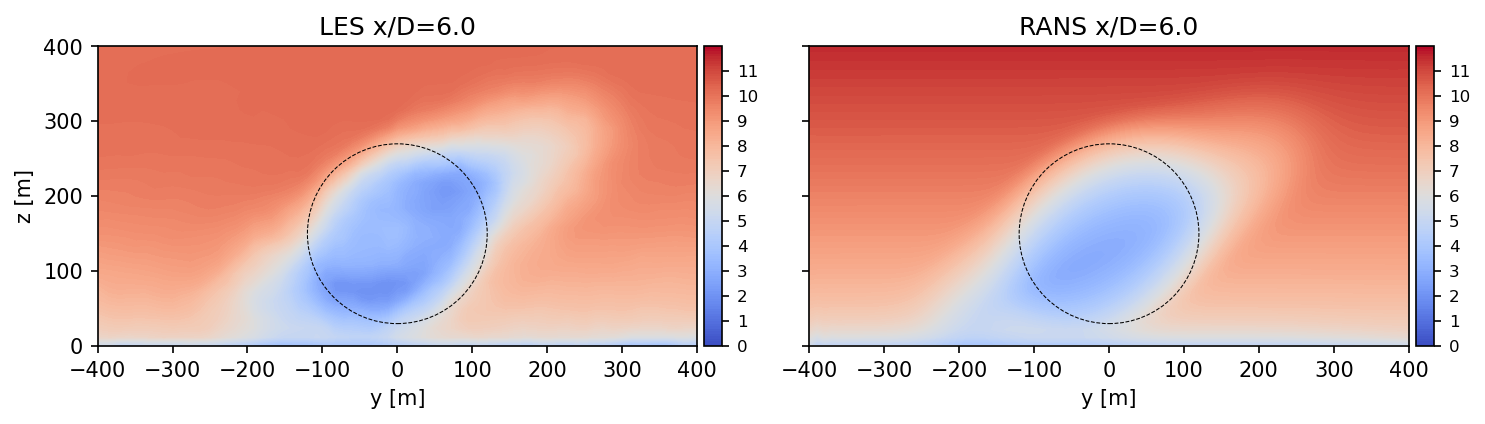

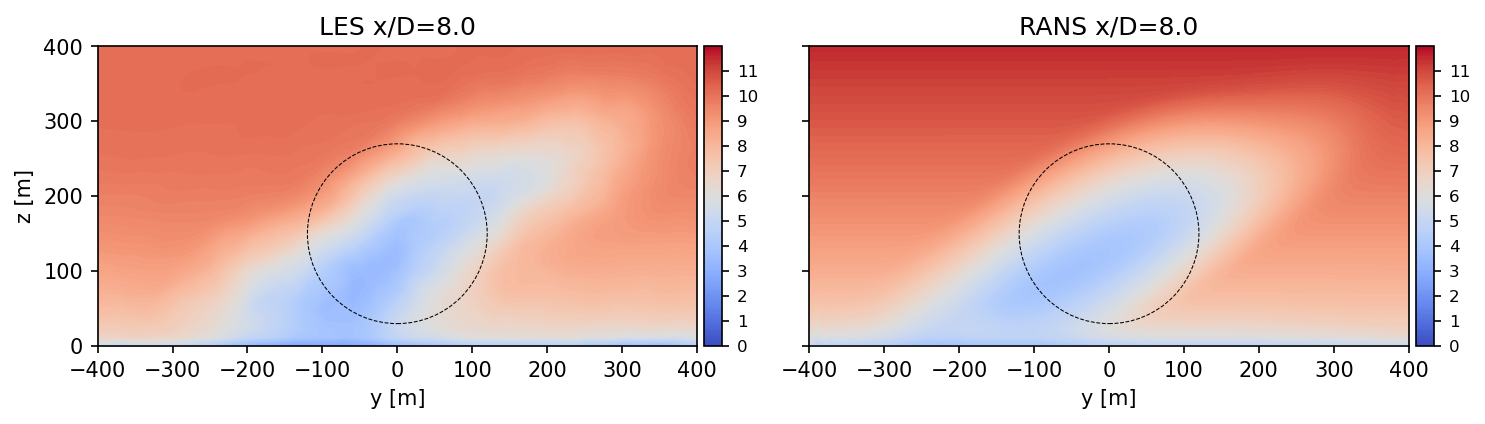

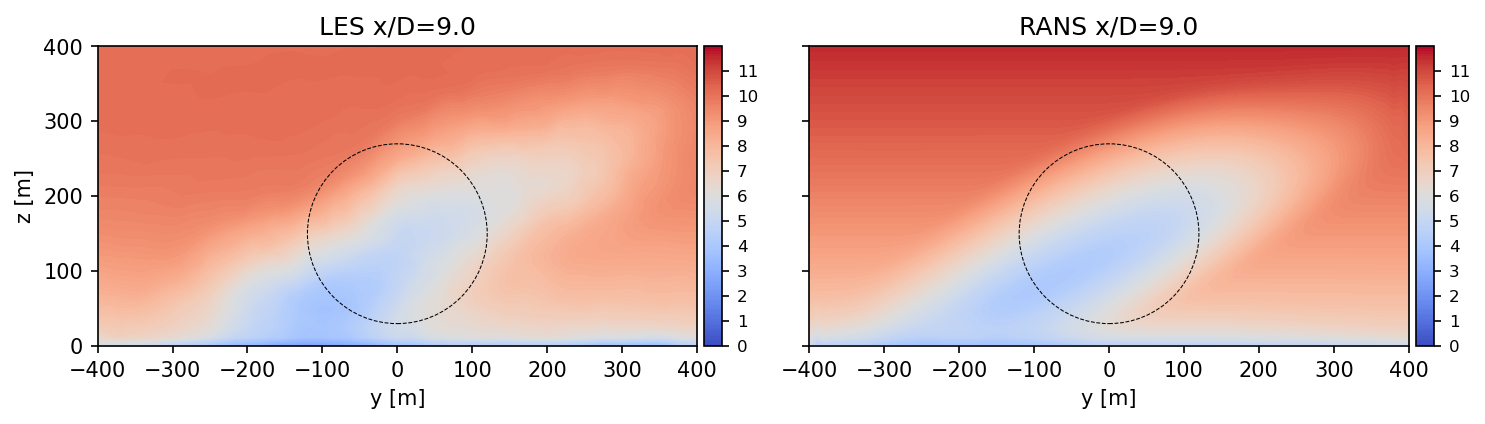

In [11]:
for plotd in plotdict:
    fig, axs = plt.subplots(1,2,figsize=(10,2.75), dpi=150, sharey=True)
    plotv = plotd['RANS_plotvar']
    turbD = plotd['turbD']
    turbhh= plotd['turbhh']
    c ={}
    # --- Do the LES plot ---
    ix      = 0
    YZ_wake = loadpickle(plotd['LES_YZfile'])
    ii      = plotd['LES_iplane']
    xplot=np.mean((YZ_wake['x'][[ii],:,:]-plotd['LES_turbx']))/turbD
    #print(xplot)
    
    c[ix]=axs[ix].contourf(-(YZ_wake['y'][ii,:,:]-plotd['LES_turby']), 
                            YZ_wake['z'][ii,:,:],
                            YZ_wake['velocityx_avg'][ii,:,:],
                            levels=vlevels[plotv]['levels'], cmap='coolwarm')
    
    # --- Do the RANS plot ---
    ix=1
    x=plotd['RANS_turbx']+turbD*xplot
    ixRANS = find_nearest(xvec, x)
    #print((xvec[ixRANS]-plotd['RANS_turbx'])/turbD)
    c[ix]=axs[ix].contourf(params['ym'], params['zm'], phi[plotv][ixRANS,:,:], levels=vlevels[plotv]['levels'], cmap='coolwarm')

    # --- Do the FLORIS plot ---
    """
    ix=2
    cross_plane = fmodel.calculate_cross_plane(
        y_resolution=250,
        z_resolution=250,
        downstream_dist=xplot*turbD+plotd['LES_turbx'],
        y_bounds=(0,prob_hi[1]),
        z_bounds=(0,prob_hi[2])
    )
    cut_plane = cross_plane
    c[ix] = axs[ix].tricontourf(cut_plane.df.x1-plotd['LES_turby'],
                                cut_plane.df.x2,
                                cut_plane.df.u,
                                levels=vlevels[plotv]['levels'], 
                                cmap='coolwarm'
                               )
    """
    # Format the plots
    for ix, ax in enumerate(axs[:]):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="3%", pad=0.05)
        cbar=fig.colorbar(c[ix], ax=axs[ix], cax=cax, ticks = matplotlib.ticker.FixedLocator(vlevels[plotv]['cbarticks']))
        cbar.ax.tick_params(labelsize=8)


        ax.set_aspect('equal')
        ax.set_ylim([0,400])
        ax.set_xlim([-400,400])
        rotorcirc = plt.Circle((0.0, turbhh), 0.5*turbD, color='k', linestyle='--', lw=0.5, fill=False)
        ax.add_patch(rotorcirc)
        ax.set_xlabel('y [m]')
        
    axs[0].set_ylabel('z [m]')
    axs[0].set_title(f'LES x/D={xplot}')
    axs[1].set_title(f'RANS x/D={xplot}')
    #axs[2].set_title(f'FLORIS x/D={xplot}')
    plt.tight_layout()
    
    if savefigs and len(plotd['savefig'])>0:
        plt.savefig(plotd['savefig'])

## Compare YZ plane TKE

In [12]:

plotdict = [
    # x/D = 2
    {'LES_YZfile':'YZplanes/YZ_wake3_TKE.pkl', 
     'LES_turbx':LES_turbx, 
     'LES_turby':LES_turby, 
     'LES_iplane':0,  
     'LES_plotfunc':plotLESTKE,
     'RANS_turbx':RANS_turbx,
     'RANS_plotvar':'k',
     'turbD':turbD,
     'turbhh':turbhh,
     'savefig':figdir+'/MedWS_LowTI_2Turb_LES_RANS_TKE_YZ_2D.png',
    },
    
    # x/D = 4
    {'LES_YZfile':'YZplanes/YZ_wake3_TKE.pkl', 
     'LES_turbx':LES_turbx, 
     'LES_turby':LES_turby, 
     'LES_iplane':4,  
     'LES_plotfunc':plotLESTKE,
     'RANS_turbx':RANS_turbx,
     'RANS_plotvar':'k',
     'turbD':turbD,
     'turbhh':turbhh,
     'savefig':figdir+'/MedWS_LowTI_2Turb_LES_RANS_TKE_YZ_4D.png',
    },

    # x/D = 5
    {'LES_YZfile':'YZplanes/YZ_wake4_TKE.pkl', 
     'LES_turbx':LES_turbx, 
     'LES_turby':LES_turby, 
     'LES_iplane':0,  
     'LES_plotfunc':plotLESTKE,
     'RANS_turbx':RANS_turbx,
     'RANS_plotvar':'k',
     'turbD':turbD,
     'turbhh':turbhh,
     'savefig':figdir+'/MedWS_LowTI_2Turb_LES_RANS_TKE_YZ_5D.png',
    },
    
    # x/D = 6
    {'LES_YZfile':'YZplanes/YZ_wake4_TKE.pkl', 
     'LES_turbx':LES_turbx, 
     'LES_turby':LES_turby, 
     'LES_iplane':1,  
     'LES_plotfunc':plotLESTKE,
     'RANS_turbx':RANS_turbx,
     'RANS_plotvar':'k',
     'turbD':turbD,
     'turbhh':turbhh,
     'savefig':figdir+'/MedWS_LowTI_2Turb_LES_RANS_TKE_YZ_6D.png',
    },

    # x/D = 8
    {'LES_YZfile':'YZplanes/YZ_wake4_TKE.pkl', 
     'LES_turbx':LES_turbx, 
     'LES_turby':LES_turby, 
     'LES_iplane':3,  
     'LES_plotfunc':plotLESTKE,
     'RANS_turbx':RANS_turbx,
     'RANS_plotvar':'k',
     'turbD':turbD,
     'turbhh':turbhh,
     'savefig':figdir+'/MedWS_LowTI_2Turb_LES_RANS_TKE_YZ_8D.png',
    },

    # x/D = 9
    {'LES_YZfile':'YZplanes/YZ_wake4_TKE.pkl', 
     'LES_turbx':LES_turbx, 
     'LES_turby':LES_turby, 
     'LES_iplane':4,  
     'LES_plotfunc':plotLESTKE,
     'RANS_turbx':RANS_turbx,
     'RANS_plotvar':'k',
     'turbD':turbD,
     'turbhh':turbhh,
     'savefig':figdir+'/MedWS_LowTI_2Turb_LES_RANS_TKE_YZ_9D.png',
    },
]

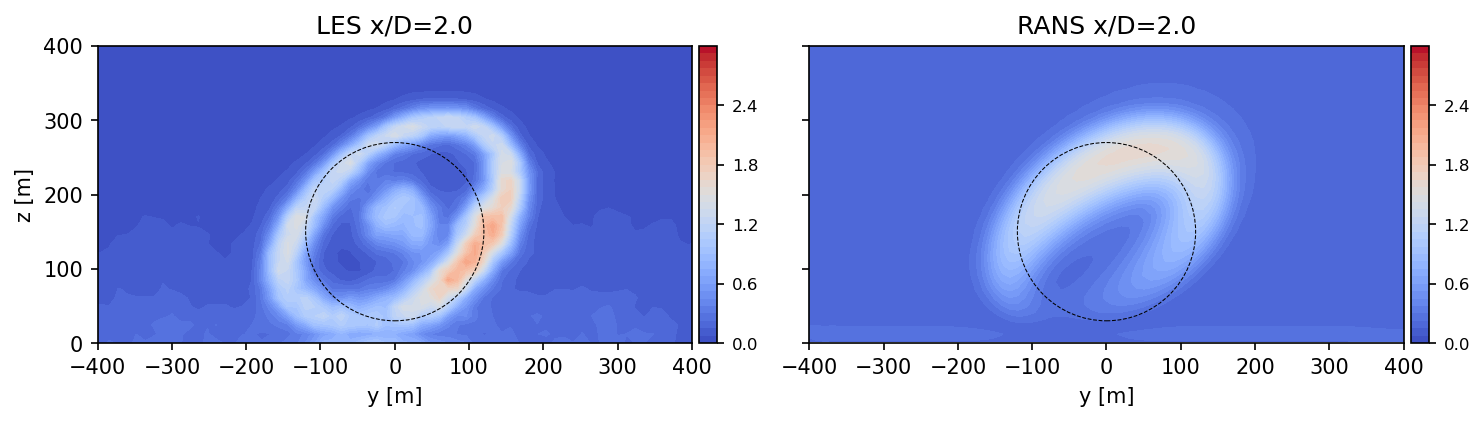

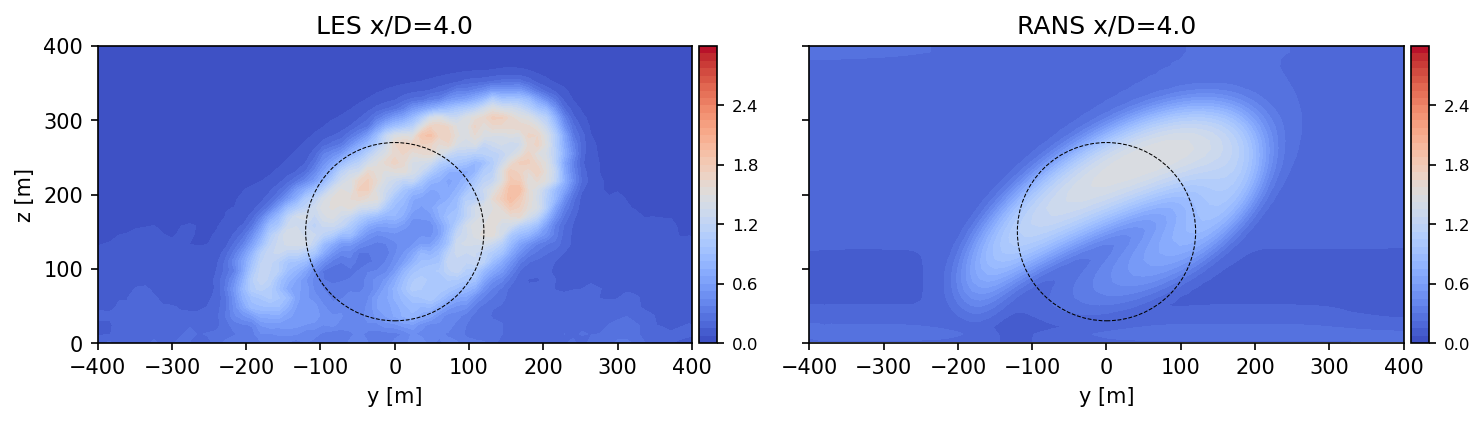

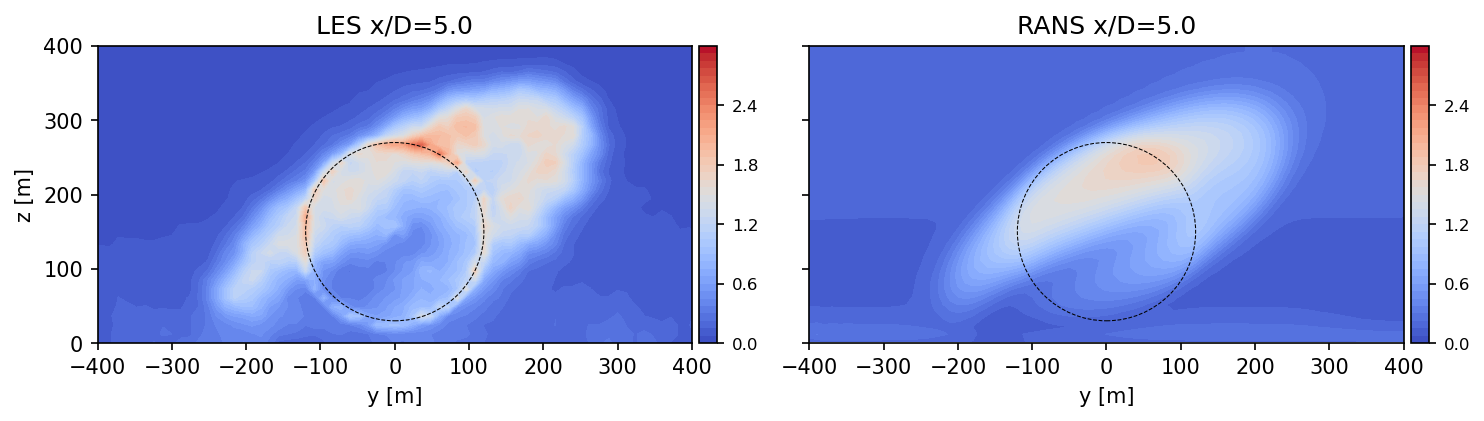

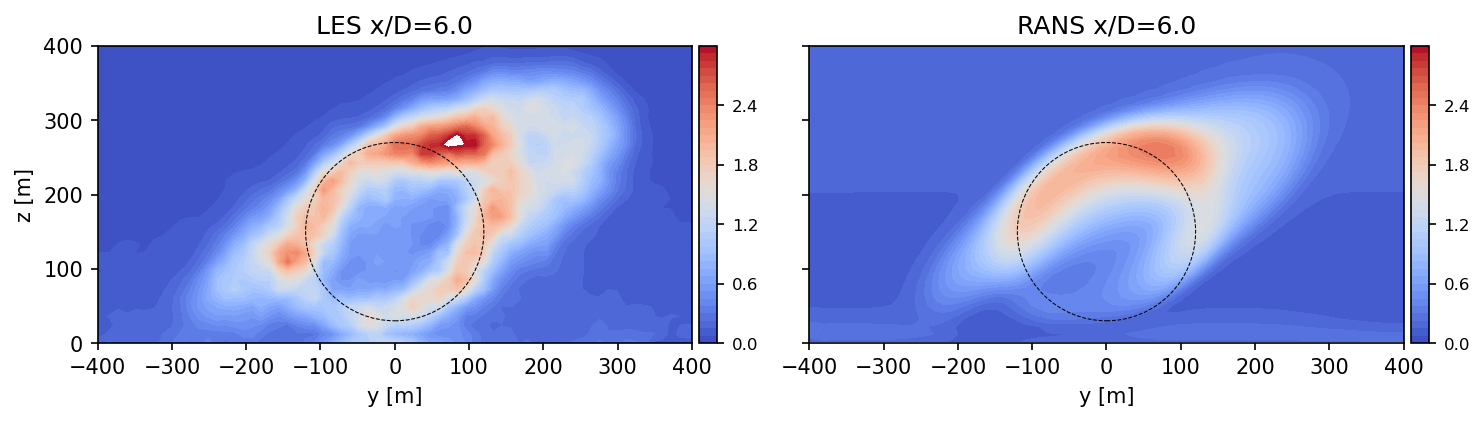

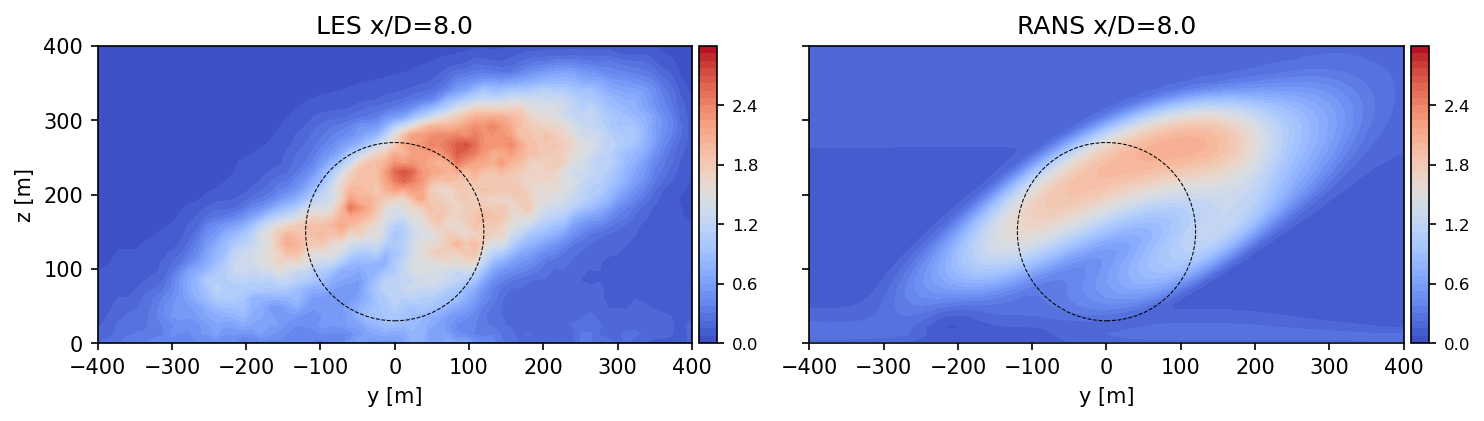

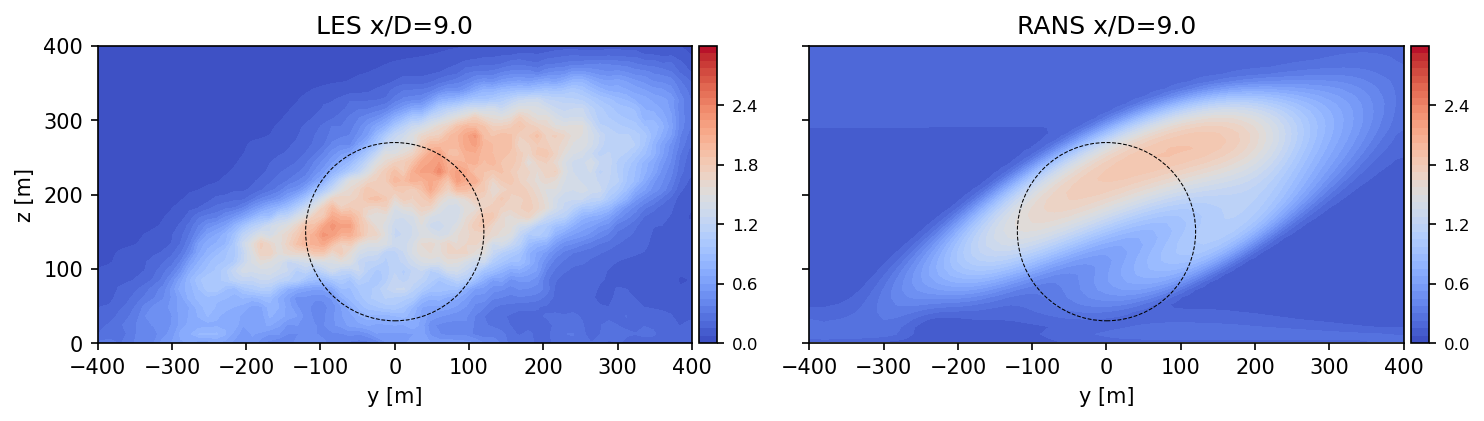

In [13]:
for plotd in plotdict:
    fig, axs = plt.subplots(1,2,figsize=(10,2.75), dpi=150, sharey=True)
    plotv = plotd['RANS_plotvar']
    turbD = plotd['turbD']
    turbhh= plotd['turbhh']
    
    # Do the LES plot
    ix      = 0
    YZ_wake = loadpickle(plotd['LES_YZfile'])
    plotfunc= plotd['LES_plotfunc']
    ii      = plotd['LES_iplane']
    xplot=np.mean((YZ_wake['x'][[ii],:,:]-plotd['LES_turbx']))/turbD
    
    c=axs[ix].contourf(-(YZ_wake['y'][ii,:,:]-plotd['LES_turby']), 
                        YZ_wake['z'][ii,:,:],
                        plotfunc(YZ_wake, ii),
                        levels=vlevels[plotv]['levels'], cmap='coolwarm')
    divider = make_axes_locatable(axs[ix])
    cax = divider.append_axes("right", size="3%", pad=0.05)
    cbar=fig.colorbar(c, ax=axs[ix], cax=cax, ticks = matplotlib.ticker.FixedLocator(vlevels[plotv]['cbarticks']))
    cbar.ax.tick_params(labelsize=8)
    
    # Do the RANS plot
    ix=1
    x=plotd['RANS_turbx']+turbD*xplot
    ixRANS = find_nearest(xvec, x)
    #print((xvec[ixRANS]-plotd['RANS_turbx'])/turbD)
    c=axs[ix].contourf(params['ym'], params['zm'], phi[plotv][ixRANS,:,:], levels=vlevels[plotv]['levels'], cmap='coolwarm')
    
    divider = make_axes_locatable(axs[ix])
    cax = divider.append_axes("right", size="3%", pad=0.05)
    cbar=fig.colorbar(c, ax=axs[ix], cax=cax, ticks = matplotlib.ticker.FixedLocator(vlevels[plotv]['cbarticks']))
    cbar.ax.tick_params(labelsize=8)

    # Format the plots
    for ax in axs:
        ax.set_aspect('equal')
        ax.set_ylim([0,400])
        ax.set_xlim([-400,400])
        rotorcirc = plt.Circle((0.0, turbhh), 0.5*turbD, color='k', linestyle='--', lw=0.5, fill=False)
        ax.add_patch(rotorcirc)
        ax.set_xlabel('y [m]')
        
    axs[0].set_ylabel('z [m]')
    axs[0].set_title(f'LES x/D={xplot}')
    axs[1].set_title(f'RANS x/D={xplot}')
    plt.tight_layout()
    
    if savefigs and len(plotd['savefig'])>0:
        plt.savefig(plotd['savefig'])